In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('./data/sign_mnist_train.csv')
test = pd.read_csv('./data/sign_mnist_test.csv')

In [3]:
train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [4]:
# train = train.to_numpy()
# train = train / 255
# print(train)

In [5]:
train_label = tf.keras.utils.to_categorical(train['label'])
test_label = tf.keras.utils.to_categorical(test['label'])
train.drop('label', axis=1, inplace=True)
test.drop('label', axis=1, inplace=True)

In [6]:
train = tf.convert_to_tensor(train / 255.0)
test = tf.convert_to_tensor(test / 255.0)
test = tf.convert_to_tensor(test)

In [7]:
train = tf.reshape(train, [-1, 28, 28,1])
test = tf.reshape(test, [-1, 28, 28,1])

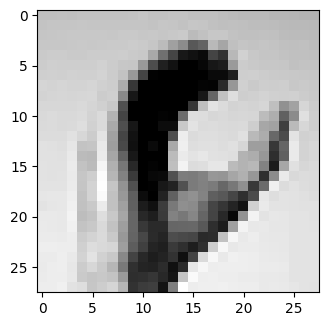

In [8]:
import random

def show_images(image):
    image = image.numpy().reshape(28,28)
    plt.figure(figsize=(8, 8))
    plt.subplot(1,2,2)
    plt.imshow(image, cmap='gray')

# for number_image in range(10):
#     show_images(train[number_image])

show_images(train[random.randrange(0,len(train)-1)])

In [9]:
train_label = tf.convert_to_tensor(train_label)
test_label = tf.convert_to_tensor(test_label)

In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((train, train_label))
test_ds = tf.data.Dataset.from_tensor_slices((test, test_label))

In [11]:
train.shape

TensorShape([27455, 28, 28, 1])

In [12]:
# image_gen = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1./255.0,
#     rotation_range=40,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     zoom_range=0.2,
#     shear_range=0.2,
#     fill_mode='nearest'
# )

In [13]:
# train_ds = image_gen.flow(
#     x=train,
#     y=train_label,
#     batch_size=32
# )
# test_ds = image_gen.flow(
#     x=test,
#     y=test_label,
#     batch_size=32
# )

In [14]:
final_train_ds, final_val_ds = tf.keras.utils.split_dataset(train_ds, left_size=0.8)

In [15]:
final_train_ds = final_train_ds.batch(32)
final_val_ds = final_val_ds.batch(32)

In [16]:
aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [17]:
model = tf.keras.Sequential([])
model.add(tf.keras.Input(shape=(28,28,1)))
model.add(aug)
model.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (3,3), activation='relu'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(25, activation='softmax'))

In [18]:
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.001), metrics=['accuracy'])

In [19]:
history = model.fit(final_train_ds, epochs=20, validation_data=final_val_ds)

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2991 - loss: 2.2829 - val_accuracy: 0.6156 - val_loss: 1.2242
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5959 - loss: 1.2509 - val_accuracy: 0.7516 - val_loss: 0.7160
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7309 - loss: 0.8091 - val_accuracy: 0.8073 - val_loss: 0.5354
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8095 - loss: 0.5740 - val_accuracy: 0.8694 - val_loss: 0.3680
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8527 - loss: 0.4445 - val_accuracy: 0.8929 - val_loss: 0.2918
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8856 - loss: 0.3510 - val_accuracy: 0.9155 - val_loss: 0.2378
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9078 - loss: 0.2799 - val_accuracy: 0.9445 - val_loss: 0.1670
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9200 - loss: 0.2459 - val_accuracy: 0.

In [21]:
loss, accuracy = model.evaluate(test, test_label, batch_size=32)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8908 - loss: 0.4519


In [22]:
prediction = model.predict(test)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(test_label, prediction)